# Modelling and simulating the evolution of cooperation

In [29]:
%matplotlib inline
import warnings

# Ignore warnings triggered for ploting
warnings.filterwarnings("ignore")

import numpy as np
import random
import matplotlib.pyplot as plt
import copy
from pyics import Model, GUI

### Default Payoff Table

In [30]:
# (A_action, B_action): A_payoff
# 0 = Cooperate, 1 = Defect
PAYOFF_TABLE = {
    (0, 0): 3,
    (0, 1): 0,
    (1, 0): 5,
    (1, 1): 1
}

### Original Strategies

In [31]:
# Dictionary containing TitForTat and 10 original strategies
# Gene encoding: [Initial, CC, CD, DC, DD]
FIXED_ENV_STRATEGIES = {
    "TitForTat":    [0, 0, 1, 0, 1],  # Starts with Cooperation. Then replicates opponent's previous move.
    "AllC":         [0, 0, 0, 0, 0],  # Always Cooperates.
    "AllD":         [1, 1, 1, 1, 1],  # Always Defects.
    "Vengeful":         [0, 0, 1, 1, 1],  # Cooperates until opponent defects once, then never forgives (always defects).
    "Ambitious":       [0, 0, 1, 1, 0],  # Win-Stay, Lose-Shift. Repeats move if payoff was high, switches if payoff was low.
    "NegativeTFT":       [1, 0, 1, 0, 1],  # Suspicious Tit-For-Tat. Same behavior as TfT but starts by Defecting.
    "Opposing":        [1, 1, 0, 1, 0],  # Defects against cooperators, but cooperates if punished by defection.
    "Mean":       [0, 1, 0, 0, 0],  # Starts nice, but occasionally defects to test for exploitability.
    "Forgiving":   [0, 0, 1, 0, 0],  # Retaliates against Defection but attempts to restore cooperation after mutual defection.
    "Alternating":       [0, 1, 1, 0, 0],  # Follows a fixed cycle regardless of the opponent's actions.
    "Diversifying":    [0, 1, 0, 0, 1]   # Win-shift, lose-stay. Switches action when winning, keeps action when losing.
}

### Support Functions

In [32]:

def get_move(gene, history_own, history_opp):
    """
    Decides the next move based on the gene and history.
    Gene indices: 0=Init, 1=(C,C), 2=(C,D), 3=(D,C), 4=(D,D).
    """
    if not history_own:
        return gene[0]

    prev_own = history_own[-1]
    prev_opp = history_opp[-1]

    # Map history (prev_own, prev_opp) to gene index 1-4
    idx = 1 + (prev_own * 2 + prev_opp)
    return gene[idx]

def play_game(gene_a, gene_b, rounds, payoff_table=PAYOFF_TABLE):
    """
    Simulates a repeated Prisoner's Dilemma game.
    Returns the cumulative scores for player A.
    """
    hist_a, hist_b = [], []
    score_a = 0

    for _ in range(rounds):
        move_a = get_move(gene_a, hist_a, hist_b)
        move_b = get_move(gene_b, hist_b, hist_a)

        score_a += payoff_table[(move_a, move_b)]

        hist_a.append(move_a)
        hist_b.append(move_b)

    return score_a


# Genetic Algorithm

def crossover(p1, p2):
    """Performs single-point crossover."""
    point = random.randint(1, 4)
    c1 = p1[:point] + p2[point:]
    c2 = p2[:point] + p1[point:]
    return c1, c2

def mutate(gene, rate):
    """Performs bit-flip mutation."""
    new_gene = copy.deepcopy(gene)
    for i in range(5):
        if random.random() < rate:
            new_gene[i] = 1 - new_gene[i]
    return new_gene

### Experiments Function

In [33]:
def run_tournament(strategies, rounds=200, payoff_table=PAYOFF_TABLE):
    """
    Runs a tournament and plots the results.
    """
    scores = {name: 0 for name in strategies}
    names = list(strategies.keys())
    n = len(names)

    for i in range(n):
        for j in range(i, n):
            name_a = names[i]
            name_b = names[j]
            s_a = play_game(strategies[name_a], strategies[name_b], rounds, payoff_table)
            s_b = play_game(strategies[name_b], strategies[name_a], rounds, payoff_table)
            scores[name_a] += s_a
            scores[name_b] += s_b

    return scores

### Genetic Algorithm Function

In [34]:
def evolve_best_strategy(pop_size=20, generations=50, rounds=200,
                         mutation_rate=0.05, elite_count=5, payoff_table=PAYOFF_TABLE, FIXED_ENV_STRATEGIES=FIXED_ENV_STRATEGIES):
    """
    Runs the genetic algorithm to evolve an optimal strategy against the fixed environment.
    Returns the best gene found.
    """
    population = []
    for i in range(pop_size): # randomly generate different strategies to play with the fixed ones
        gene = [random.randint(0, 1) for _ in range(5)]
        population.append({"gene": gene, "fitness": 0})

    history_avg = []
    history_best = [] # Best Fitness is the score of the highest-scoring one out of all the players in this generation.

    for gen in range(generations):
        # Evaluation
        for individual in population:
            current_score = 0
            for fixed_name, fixed_gene in FIXED_ENV_STRATEGIES.items(): # play against all original strategies
                s_ind = play_game(individual['gene'], fixed_gene, rounds, payoff_table)
                current_score += s_ind
            individual['fitness'] = current_score

        fits = [ind['fitness'] for ind in population]
        history_avg.append(sum(fits) / pop_size)
        history_best.append(max(fits))

        # Selection based on their fitness (score)
        population.sort(key=lambda x: x['fitness'], reverse=True)
        elites = population[:elite_count]

        # Next Gen
        next_gen = []
        next_gen.extend(copy.deepcopy(elites))
        while len(next_gen) < pop_size:
            p1 = random.choice(elites)
            p2 = random.choice(elites)
            c1, c2 = crossover(p1['gene'], p2['gene'])
            next_gen.append({"gene": mutate(c1, mutation_rate), "fitness": 0})
            if len(next_gen) < pop_size:
                next_gen.append({"gene": mutate(c2, mutation_rate), "fitness": 0})
        population = next_gen

    plt.figure(figsize=(10, 5))
    plt.plot(history_avg, label='Average Fitness', color='blue')
    plt.plot(history_best, label='Best Fitness', color='green', linestyle='--')
    plt.title('Genetic Algorithm Evolution Process')
    plt.xlabel('Generation')
    plt.ylabel('Fitness')
    plt.legend()
    plt.show()

    population.sort(key=lambda x: x['fitness'], reverse=True)
    return population[0]['gene']

### CA Model

In [35]:
# CA Model for GUI
class CASim(Model):
    def __init__(self):
        Model.__init__(self)

        self.t = 0
        self.config = None
        self.current_genes = []

        # Parameters compatible with pyics
        self.make_param('width', 50)
        self.make_param('height', 100)
        self.make_param('T', 50)
        self.make_param('mutation_rate', 0.01)
        self.make_param('random_init', True)

    def reset(self):
        """Initialize the grid and strategies."""
        self.t = 0
        self.config = np.zeros([self.height, self.width], dtype=int)
        self.current_genes = []

        # Initialize row 0
        if self.random_init:
            for _ in range(self.width):
                self.current_genes.append([random.randint(0, 1) for _ in range(5)])
        else:
            # Fixed pattern: All-D with TfT in middle
            for _ in range(self.width):
                self.current_genes.append([1, 1, 1, 1, 1])
            mid = self.width // 2
            self.current_genes[mid] = [0, 0, 1, 0, 1]

        # Visualization update
        for x in range(self.width):
            self.config[0, x] = int("".join(map(str, self.current_genes[x])), 2)

    def step(self):
        """Perform one generation of spatial evolution."""
        self.t += 1
        if self.t >= self.height:
            return True

        width = self.width
        scores = [0] * width

        # Interaction (Play against neighbors)
        for x in range(width):
            left_idx = (x - 1) % width
            right_idx = (x + 1) % width

            me = self.current_genes[x]
            left = self.current_genes[left_idx]
            right = self.current_genes[right_idx]

            # Score is sum of games against left and right neighbors
            score = play_game(me, left, self.T) + play_game(me, right, self.T)
            scores[x] = score

        # Selection (Copy Best Neighbor's Behavior)
        next_genes = []
        for x in range(width):
            left_idx = (x - 1) % width
            right_idx = (x + 1) % width

            # Compare self, left, and right
            candidates_idx = [left_idx, x, right_idx]
            best_idx = max(candidates_idx, key=lambda i: scores[i])

            winning_gene = copy.deepcopy(self.current_genes[best_idx])

            # Mutation
            final_gene = mutate(winning_gene, self.mutation_rate)
            next_genes.append(final_gene)

        self.current_genes = next_genes

        # Update visualization
        for x in range(width):
            self.config[self.t, x] = int("".join(map(str, self.current_genes[x])), 2)

    def draw(self):
        """Draws the CA grid."""
        plt.cla()
        if not plt.gca().yaxis_inverted():
            plt.gca().invert_yaxis()
        # Use nipy_spectral to distinguish the 32 possible strategies
        plt.imshow(self.config, interpolation='none', vmin=0, vmax=31,
                cmap='nipy_spectral', aspect='auto')
        plt.axis('image')
        plt.title(f'Generation: {self.t}')

### Experiments

Running Tournament Visualization for 3 scenarios...
Scores for Standard: {'TitForTat': 1568, 'AllC': 1272, 'AllD': 1704, 'Vengeful': 1876, 'Ambitious': 1688, 'NegativeTFT': 1217, 'Opposing': 1582, 'Mean': 987, 'Forgiving': 1500, 'Alternating': 1263, 'Diversifying': 983}
Scores for High Temptation: {'TitForTat': 1847, 'AllC': 1272, 'AllD': 2532, 'Vengeful': 2383, 'Ambitious': 2063, 'NegativeTFT': 1640, 'Opposing': 2215, 'Mean': 1218, 'Forgiving': 1743, 'Alternating': 1641, 'Diversifying': 1298}
Scores for Severe Punishment: {'TitForTat': 1506, 'AllC': 1272, 'AllD': 1380, 'Vengeful': 1754, 'Ambitious': 1618, 'NegativeTFT': 990, 'Opposing': 1445, 'Mean': 895, 'Forgiving': 1458, 'Alternating': 1089, 'Diversifying': 855}


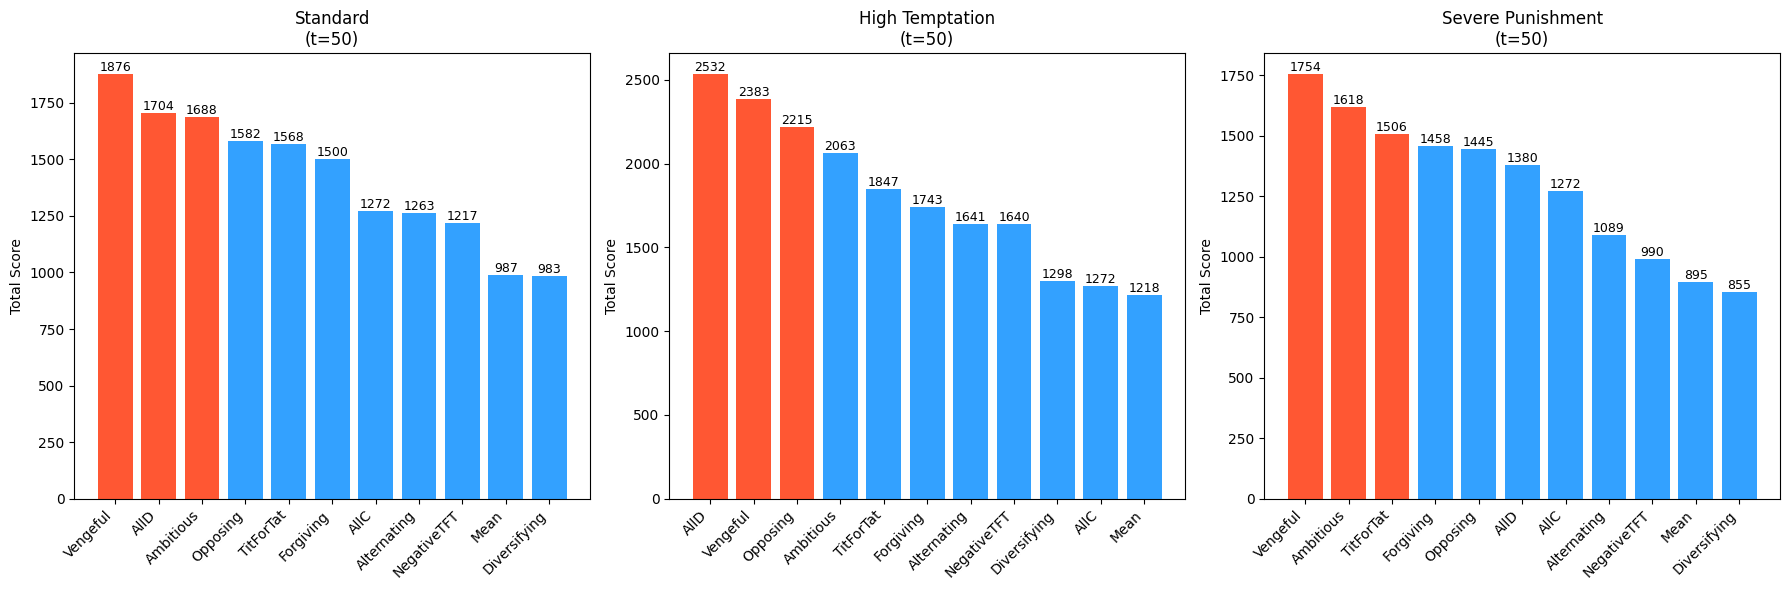

In [36]:
# Define the scenarios
scenarios = {
    "Standard": PAYOFF_TABLE,
    "High Temptation": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 8, (1, 1): 1
    },
    "Severe Punishment": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 5, (1, 1): 0
    }
}

# Settings
rounds = 50 # Tournament rounds
num_scenarios = len(scenarios)

# Create a figure with subplots (1 row, N columns)
fig, axes = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6))

# If there is only 1 scenario, wrap axes in a list to make it iterable
if num_scenarios == 1:
    axes = [axes]
elif isinstance(axes, np.ndarray):
    axes = axes.flatten()

print(f"Running Tournament Visualization for {num_scenarios} scenarios...")

# Loop through scenarios and plot on specific axis
for idx, (scenario_name, pt) in enumerate(scenarios.items()):
    ax = axes[idx] # Get the specific subplot axis

    # Calculate Scores
    scores = run_tournament(FIXED_ENV_STRATEGIES, rounds=rounds, payoff_table=pt)
    print(f"Scores for {scenario_name}: {scores}")

    # Sort Data
    sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
    sorted_names = [item[0] for item in sorted_scores]
    sorted_values = [item[1] for item in sorted_scores]

    # Plot Bars
    colors = ['#FF5733' if i < 3 else '#33A1FF' for i in range(len(sorted_names))]
    
    x_positions = range(len(sorted_names))
    clean_values = [int(v) for v in sorted_values]
    
    bars = ax.bar(x_positions, clean_values, color=colors)

    # Styling
    ax.set_title(f'{scenario_name}\n(t={rounds})')
    ax.set_ylabel('Total Score')
    
    # 【关键修复】：先定刻度位置，再贴标签
    ax.set_xticks(x_positions) 
    ax.set_xticklabels(sorted_names, rotation=45, ha='right')

    # Add Value Labels
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                va='bottom', ha='center', fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()

Running Tournament Visualization for 3 scenarios...
Scores for Standard: {'TitForTat': 6309, 'AllC': 5097, 'AllD': 6804, 'Vengeful': 7576, 'Ambitious': 6802, 'NegativeTFT': 4828, 'Opposing': 6309, 'Mean': 3887, 'Forgiving': 6025, 'Alternating': 5010, 'Diversifying': 3871}
Scores for High Temptation: {'TitForTat': 7452, 'AllC': 5097, 'AllD': 10107, 'Vengeful': 9658, 'Ambitious': 8341, 'NegativeTFT': 6487, 'Opposing': 8817, 'Mean': 4793, 'Forgiving': 7018, 'Alternating': 6513, 'Diversifying': 5125}
Scores for Severe Punishment: {'TitForTat': 6060, 'AllC': 5097, 'AllD': 5505, 'Vengeful': 7079, 'Ambitious': 6519, 'NegativeTFT': 3914, 'Opposing': 5773, 'Mean': 3520, 'Forgiving': 5858, 'Alternating': 4311, 'Diversifying': 3356}


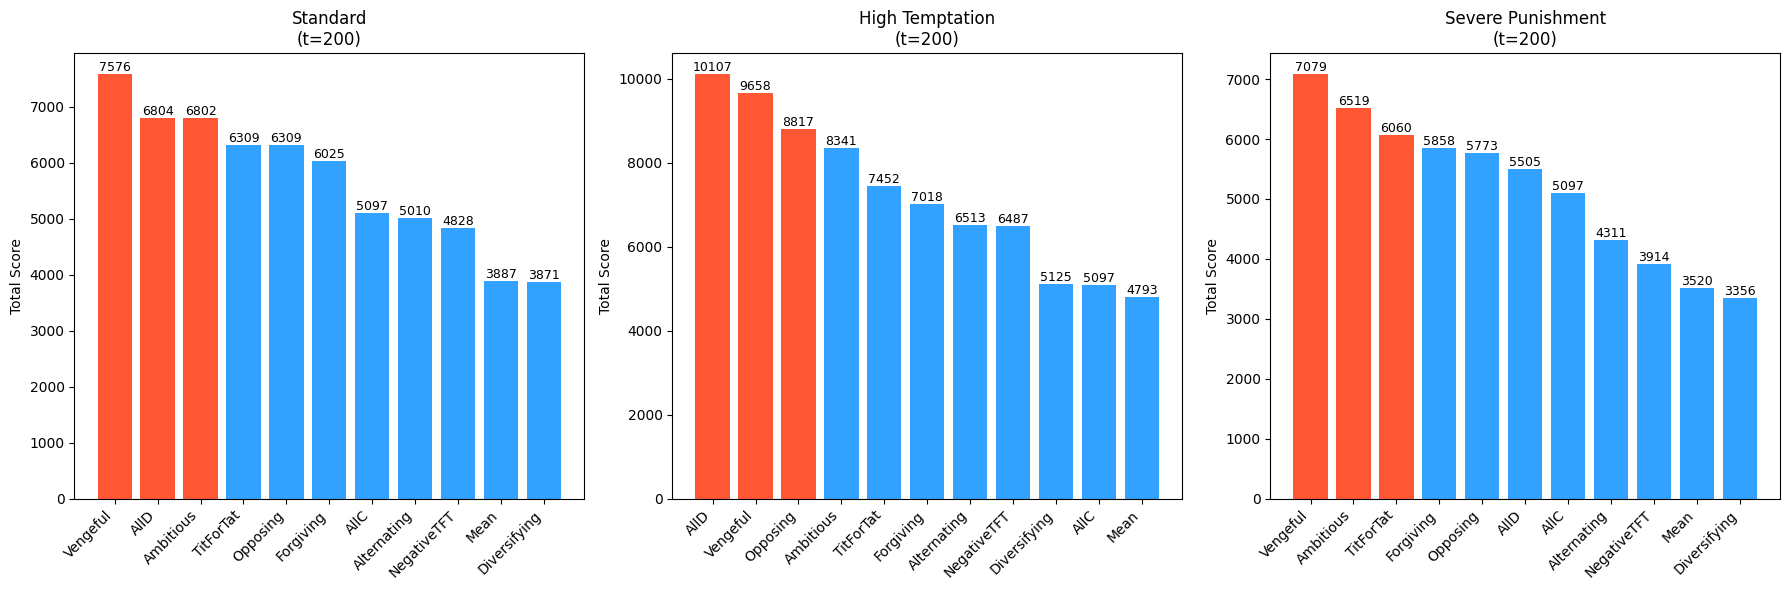

In [37]:
# Define the scenarios
scenarios = {
    "Standard": PAYOFF_TABLE,
    "High Temptation": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 8, (1, 1): 1
    },
    "Severe Punishment": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 5, (1, 1): 0
    }
}

# Settings
rounds = 200 # Tournament rounds
num_scenarios = len(scenarios)

# Create a figure with subplots (1 row, N columns)
fig, axes = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6))

# If there is only 1 scenario, wrap axes in a list to make it iterable
if num_scenarios == 1:
    axes = [axes]
elif isinstance(axes, np.ndarray):
    axes = axes.flatten()

print(f"Running Tournament Visualization for {num_scenarios} scenarios...")

# Loop through scenarios and plot on specific axis
for idx, (scenario_name, pt) in enumerate(scenarios.items()):
    ax = axes[idx] # Get the specific subplot axis

    # Calculate Scores
    scores = run_tournament(FIXED_ENV_STRATEGIES, rounds=rounds, payoff_table=pt)
    print(f"Scores for {scenario_name}: {scores}")

    # Sort Data
    sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
    sorted_names = [item[0] for item in sorted_scores]
    sorted_values = [item[1] for item in sorted_scores]

    # Plot Bars
    colors = ['#FF5733' if i < 3 else '#33A1FF' for i in range(len(sorted_names))]
    
    x_positions = range(len(sorted_names))
    clean_values = [int(v) for v in sorted_values]
    
    bars = ax.bar(x_positions, clean_values, color=colors)

    # Styling
    ax.set_title(f'{scenario_name}\n(t={rounds})')
    ax.set_ylabel('Total Score')
    
    # 【关键修复】：先定刻度位置，再贴标签
    ax.set_xticks(x_positions) 
    ax.set_xticklabels(sorted_names, rotation=45, ha='right')

    # Add Value Labels
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                va='bottom', ha='center', fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()

Running Tournament Visualization for 3 scenarios...
Scores for Standard: {'TitForTat': 15784, 'AllC': 12747, 'AllD': 17004, 'Vengeful': 18976, 'Ambitious': 17027, 'NegativeTFT': 12053, 'Opposing': 15759, 'Mean': 9687, 'Forgiving': 15075, 'Alternating': 12510, 'Diversifying': 9646}
Scores for High Temptation: {'TitForTat': 18652, 'AllC': 12747, 'AllD': 25257, 'Vengeful': 24208, 'Ambitious': 20891, 'NegativeTFT': 16187, 'Opposing': 22017, 'Mean': 11943, 'Forgiving': 17568, 'Alternating': 16263, 'Diversifying': 12775}
Scores for Severe Punishment: {'TitForTat': 15160, 'AllC': 12747, 'AllD': 13755, 'Vengeful': 17729, 'Ambitious': 16319, 'NegativeTFT': 9764, 'Opposing': 14423, 'Mean': 8770, 'Forgiving': 14658, 'Alternating': 10761, 'Diversifying': 8356}


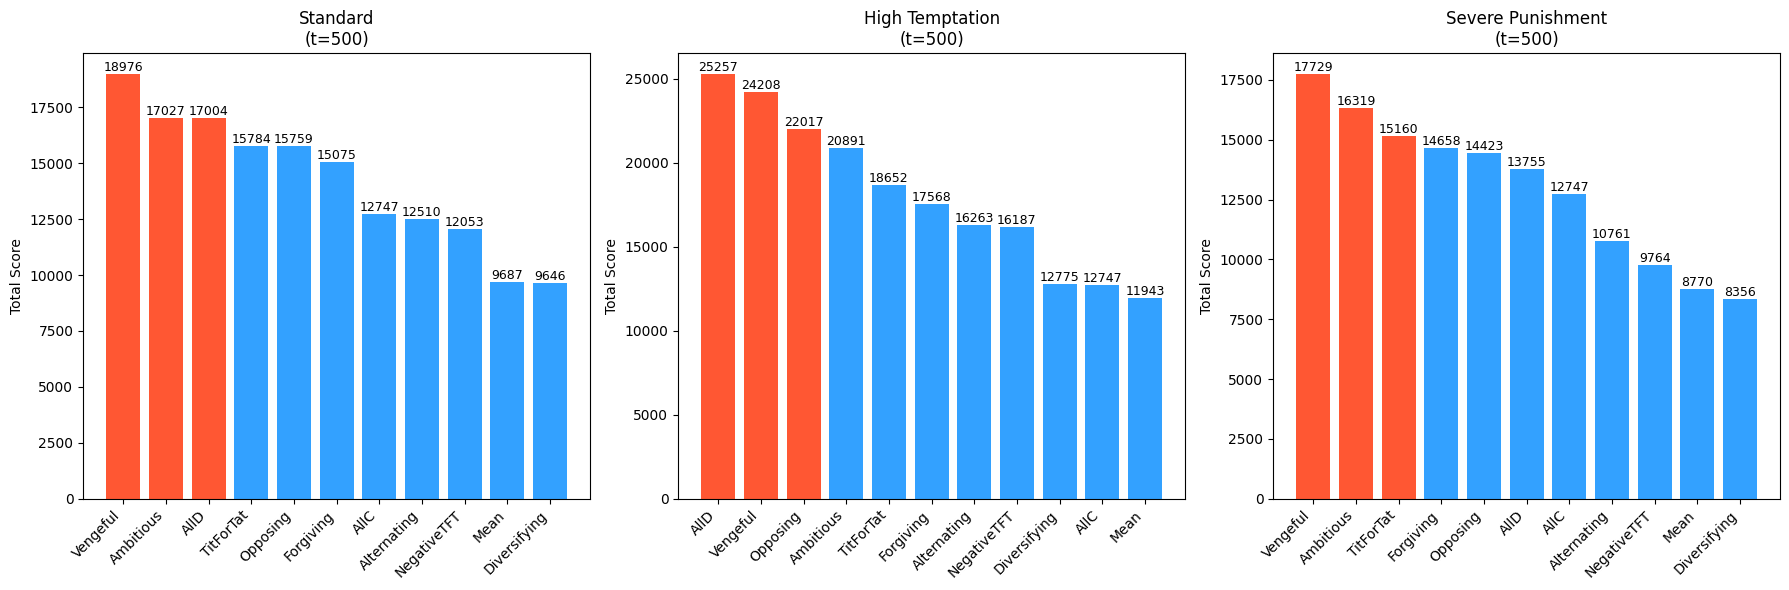

In [38]:
# Define the scenarios
scenarios = {
    "Standard": PAYOFF_TABLE,
    "High Temptation": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 8, (1, 1): 1
    },
    "Severe Punishment": {
        (0, 0): 3, (0, 1): 0,
        (1, 0): 5, (1, 1): 0
    }
}

# Settings
rounds = 500 # Tournament rounds
num_scenarios = len(scenarios)

# Create a figure with subplots (1 row, N columns)
fig, axes = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6))

# If there is only 1 scenario, wrap axes in a list to make it iterable
if num_scenarios == 1:
    axes = [axes]
elif isinstance(axes, np.ndarray):
    axes = axes.flatten()

print(f"Running Tournament Visualization for {num_scenarios} scenarios...")

# Loop through scenarios and plot on specific axis
for idx, (scenario_name, pt) in enumerate(scenarios.items()):
    ax = axes[idx] # Get the specific subplot axis

    # Calculate Scores
    scores = run_tournament(FIXED_ENV_STRATEGIES, rounds=rounds, payoff_table=pt)
    print(f"Scores for {scenario_name}: {scores}")

    # Sort Data
    sorted_scores = sorted(scores.items(), key=lambda item: item[1], reverse=True)
    sorted_names = [item[0] for item in sorted_scores]
    sorted_values = [item[1] for item in sorted_scores]

    # Plot Bars
    colors = ['#FF5733' if i < 3 else '#33A1FF' for i in range(len(sorted_names))]
    
    x_positions = range(len(sorted_names))
    clean_values = [int(v) for v in sorted_values]
    
    bars = ax.bar(x_positions, clean_values, color=colors)

    # Styling
    ax.set_title(f'{scenario_name}\n(t={rounds})')
    ax.set_ylabel('Total Score')
    
    ax.set_xticks(x_positions) 
    ax.set_xticklabels(sorted_names, rotation=45, ha='right')

    # Add Value Labels
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
                va='bottom', ha='center', fontsize=9)

# Adjust layout
plt.tight_layout()
plt.show()

### Evolve the Best Strategy

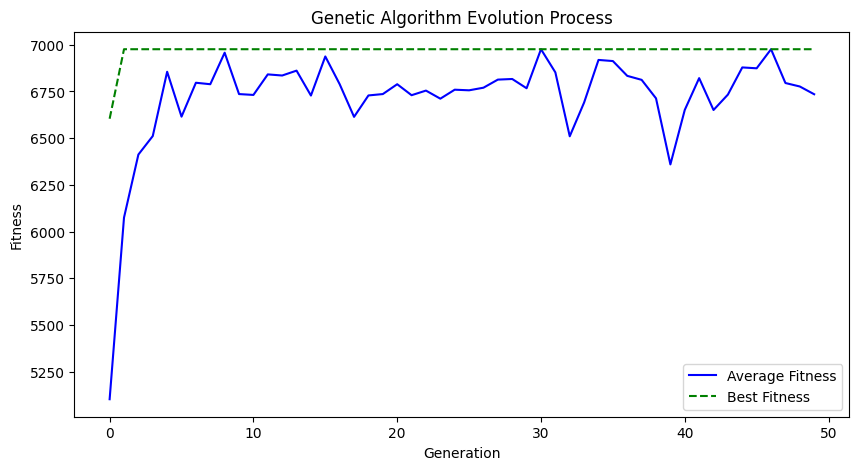

GA Best Strategy Found: [0, 0, 1, 1, 1]


In [39]:
best_strategy = evolve_best_strategy(
    pop_size=20,
    generations=50,
    rounds=200,
    mutation_rate=0.05,
    elite_count=5
)
print(f"GA Best Strategy Found: {best_strategy}")

The GA constantly finds [0, 0, 1, 1, 1], which happens to be the rule table for the 'Vengeful'-strategy.

### Experience the CA Model

In [40]:
# Uncomment to run CA GUI
# sim = CASim()
# cx = GUI(sim)
# cx.start()